In [3]:
import os

R_HOME = r"C:\Program Files\R\R-4.5.2"
R_BIN = r"C:\Program Files\R\R-4.5.2\bin\x64"

os.environ["R_HOME"] = R_HOME
os.environ["PATH"] = R_BIN + ";" + os.environ["PATH"]

os.add_dll_directory(R_BIN)

print("R_HOME:", os.environ["R_HOME"])
print("R_BIN added:", R_BIN)

R_HOME: C:\Program Files\R\R-4.5.2
R_BIN added: C:\Program Files\R\R-4.5.2\bin\x64


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import rpy2.robjects as ro
from rpy2.robjects.packages import importr
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

base = importr("base")
stats = importr("stats")
nlme = importr("nlme")
mgcv = importr("mgcv")


In [5]:
minute_path = r"data\minute_predictions_myioborus_calendar.csv"
summary_path = r"data\daily_summary_myioborus.csv"
sebas_path = r"data\Sebas_data.csv"

df_min = pd.read_csv(minute_path)
df_daily = pd.read_csv(summary_path)
df_sebas = pd.read_csv(sebas_path)

print(df_min.shape)
print(df_daily.shape)
print(df_sebas.shape)

print(df_min.columns.tolist())
print(df_daily.columns.tolist())
print(df_sebas.columns.tolist())

(299520, 14)
(184, 25)
(184, 22)
['#', 'tiempo', 'egg', 'ambient', 'tiempo_min', 'archivo', 'dia', 'minuto', 'prediccion', 'block_dia', 'block_minute', 'calendar_date', 'clock_minute', 'incubating']
['archivo', 'dia', 'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'inicio_intervalo', 'fin_intervalo', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'nido_id', 'equivalente', 'ID_del_Nido', 'Estacion', 'Especie', 'Familia', 'Elevacion', 'Huevo_Peso_g', 'Huevo_Ancho_mm', 'Huevo_Largo_mm', 'Nido_peso_Total_g', 'Altura_sobre_el_suelo_cm']
['archivo', 'dia', ' diaprox ', 'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'inicio_intervalo', 'fin_intervalo', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'nido_id', 'equivalente', 'ID_del_Nido', 'Huevo_Peso_g', ' datalogercorrec ', ' edad_huevoR

In [6]:
# Clean column names
df_min.columns = df_min.columns.str.strip()
df_daily.columns = df_daily.columns.str.strip()
df_sebas.columns = df_sebas.columns.str.strip()

print("df_min columns:")
print(df_min.columns.tolist())

print("\ndf_daily columns:")
print(df_daily.columns.tolist())

print("\ndf_sebas columns:")
print(df_sebas.columns.tolist())

df_min columns:
['#', 'tiempo', 'egg', 'ambient', 'tiempo_min', 'archivo', 'dia', 'minuto', 'prediccion', 'block_dia', 'block_minute', 'calendar_date', 'clock_minute', 'incubating']

df_daily columns:
['archivo', 'dia', 'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'inicio_intervalo', 'fin_intervalo', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'nido_id', 'equivalente', 'ID_del_Nido', 'Estacion', 'Especie', 'Familia', 'Elevacion', 'Huevo_Peso_g', 'Huevo_Ancho_mm', 'Huevo_Largo_mm', 'Nido_peso_Total_g', 'Altura_sobre_el_suelo_cm']

df_sebas columns:
['archivo', 'dia', 'diaprox', 'nest_attentiveness_day', 'duracion_total_on', 'duracion_intervalo_day', 'inicio_intervalo', 'fin_intervalo', 'avg_duracion_on', 'avg_duracion_off', 'avg_duracion_nocturnal', 'n_eventos_on', 'n_eventos_off', 'avg_temp_ambient_diaria', 'nido_id', 'equivalente', 'ID_del_Nido', 'Huevo_Peso_g', 'datalogercorre

In [7]:
# Build GAMM dataset: minute predictions + elevation + egg age
# Species: M. melanocephalus and M. miniatus only
# ============================================================

# Standardise keys
df_min["archivo"] = df_min["archivo"].astype(str).str.strip()
df_daily["archivo"] = df_daily["archivo"].astype(str).str.strip()
df_sebas["archivo"] = df_sebas["archivo"].astype(str).str.strip()

df_min["block_dia"] = pd.to_numeric(df_min["block_dia"], errors="coerce").astype("Int64")
df_min["dia_key"] = df_min["block_dia"]

df_daily["dia_key"] = pd.to_numeric(df_daily["dia"], errors="coerce").astype("Int64")
df_sebas["dia_key"] = pd.to_numeric(df_sebas["dia"], errors="coerce").astype("Int64")

df_sebas["diaprox"] = pd.to_numeric(df_sebas["diaprox"], errors="coerce")

# Daily metadata from daily_summary
daily_covars = df_daily[
    [
        "archivo",
        "dia_key",
        "Especie",
        "Estacion",
        "Elevacion",
        "Huevo_Peso_g",
        "ID_del_Nido",
        "equivalente"
    ]
].drop_duplicates()

# Egg age from Sebas_data
egg_age = df_sebas[
    [
        "archivo",
        "dia_key",
        "diaprox",
        "edad_huevoR",
        "Huevo_edadinversa",
        "Fenologia"
    ]
].drop_duplicates()

# Merge metadata + egg age at nest-day level
daily_covars = daily_covars.merge(
    egg_age,
    on=["archivo", "dia_key"],
    how="left"
)

print("daily_covars shape:", daily_covars.shape)
print(daily_covars.head())
print("Missing diaprox in daily_covars:", daily_covars["diaprox"].isna().sum())

daily_covars shape: (184, 12)
                                             archivo  dia_key  \
0  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...        0   
1  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...        1   
2  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...        3   
3  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...        4   
4  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...        5   

                    Especie   Estacion  Elevacion  Huevo_Peso_g ID_del_Nido  \
0  Myioborus_melanocephalus  San_Pedro     2263.0          1.85   TU1_DOR08   
1  Myioborus_melanocephalus  San_Pedro     2263.0          1.85   TU1_DOR08   
2  Myioborus_melanocephalus  San_Pedro     2263.0          1.85   TU1_DOR08   
3  Myioborus_melanocephalus  San_Pedro     2263.0          1.85   TU1_DOR08   
4  Myioborus_melanocephalus  San_Pedro     2263.0          1.85   TU1_DOR08   

  equivalente  diaprox edad_huevoR Huevo_edadinversa  Fenologia  
0   TU1_DOR08        4           4    

In [8]:
# Merge daily covariates into minute-level predictions
# ============================================================

df_long = df_min.merge(
    daily_covars,
    on=["archivo", "dia_key"],
    how="left"
)

# Keep only the two target species
species_keep = [
    "Myioborus_melanocephalus",
    "Myioborus_miniatus"
]

df_long = df_long[df_long["Especie"].isin(species_keep)].copy()

# Binary response for GAMM
# prediccion: 0 = Nocturnal, 1 = Off, 2 = On
# incubating: 1 = On or Nocturnal, 0 = Off
df_long["incubating"] = np.where(df_long["prediccion"].isin([0, 2]), 1, 0)

# Numeric variables
df_long["minute_of_day"] = pd.to_numeric(df_long["clock_minute"], errors="coerce")
df_long["Elevacion"] = pd.to_numeric(df_long["Elevacion"], errors="coerce")
df_long["diaprox"] = pd.to_numeric(df_long["diaprox"], errors="coerce")
df_long["Huevo_Peso_g"] = pd.to_numeric(df_long["Huevo_Peso_g"], errors="coerce")

# Random-effect IDs
df_long["Nest_ID"] = df_long["archivo"].astype(str)
df_long["NestCalendarDay_ID"] = (
    df_long["archivo"].astype(str) + "_date_" + df_long["calendar_date"].astype(str)
)
df_long["Estacion"] = df_long["Estacion"].astype(str)

# Drop incomplete rows
df_long = df_long.dropna(
    subset=[
        "incubating",
        "minute_of_day",
        "Elevacion",
        "diaprox",
        "Huevo_Peso_g",
        "Estacion",
        "Nest_ID",
        "NestCalendarDay_ID",
        "Especie"
    ]
).copy()

df_long["incubating"] = df_long["incubating"].astype(int)
df_long["minute_of_day"] = df_long["minute_of_day"].astype(int)

print("df_long shape:", df_long.shape)

print(df_long[
    [
        "archivo", "dia", "Especie", "Estacion",
        "minute_of_day", "incubating",
        "Elevacion", "diaprox", "Huevo_Peso_g"
    ]
].head())

print("\nSpecies counts:")
print(df_long["Especie"].value_counts())

print("\nUnique nests:", df_long["Nest_ID"].nunique())
print("Unique nest-days:", df_long["NestCalendarDay_ID"].nunique())
print("Unique stations:", df_long["Estacion"].nunique())

print("\nStation counts:")
print(df_long["Estacion"].value_counts())

print("\nMissing diaprox:", df_long["diaprox"].isna().sum())
print("Missing Elevacion:", df_long["Elevacion"].isna().sum())
print("Missing Huevo_Peso_g:", df_long["Huevo_Peso_g"].isna().sum())

df_long shape: (200570, 28)
                                             archivo  dia  \
0  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    0   
1  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    0   
2  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    0   
3  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    0   
4  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    0   

                    Especie   Estacion  minute_of_day  incubating  Elevacion  \
0  Myioborus_melanocephalus  San_Pedro              0           1     2263.0   
1  Myioborus_melanocephalus  San_Pedro              1           1     2263.0   
2  Myioborus_melanocephalus  San_Pedro              2           1     2263.0   
3  Myioborus_melanocephalus  San_Pedro              3           1     2263.0   
4  Myioborus_melanocephalus  San_Pedro              4           1     2263.0   

   diaprox  Huevo_Peso_g  
0      4.0          1.85  
1      4.0          1.85  
2      4.0          1.85  
3      4.0      

Complete calendar nest-days: 134
Incomplete calendar nest-days: 11
Raster matrix shape: (134, 1440)


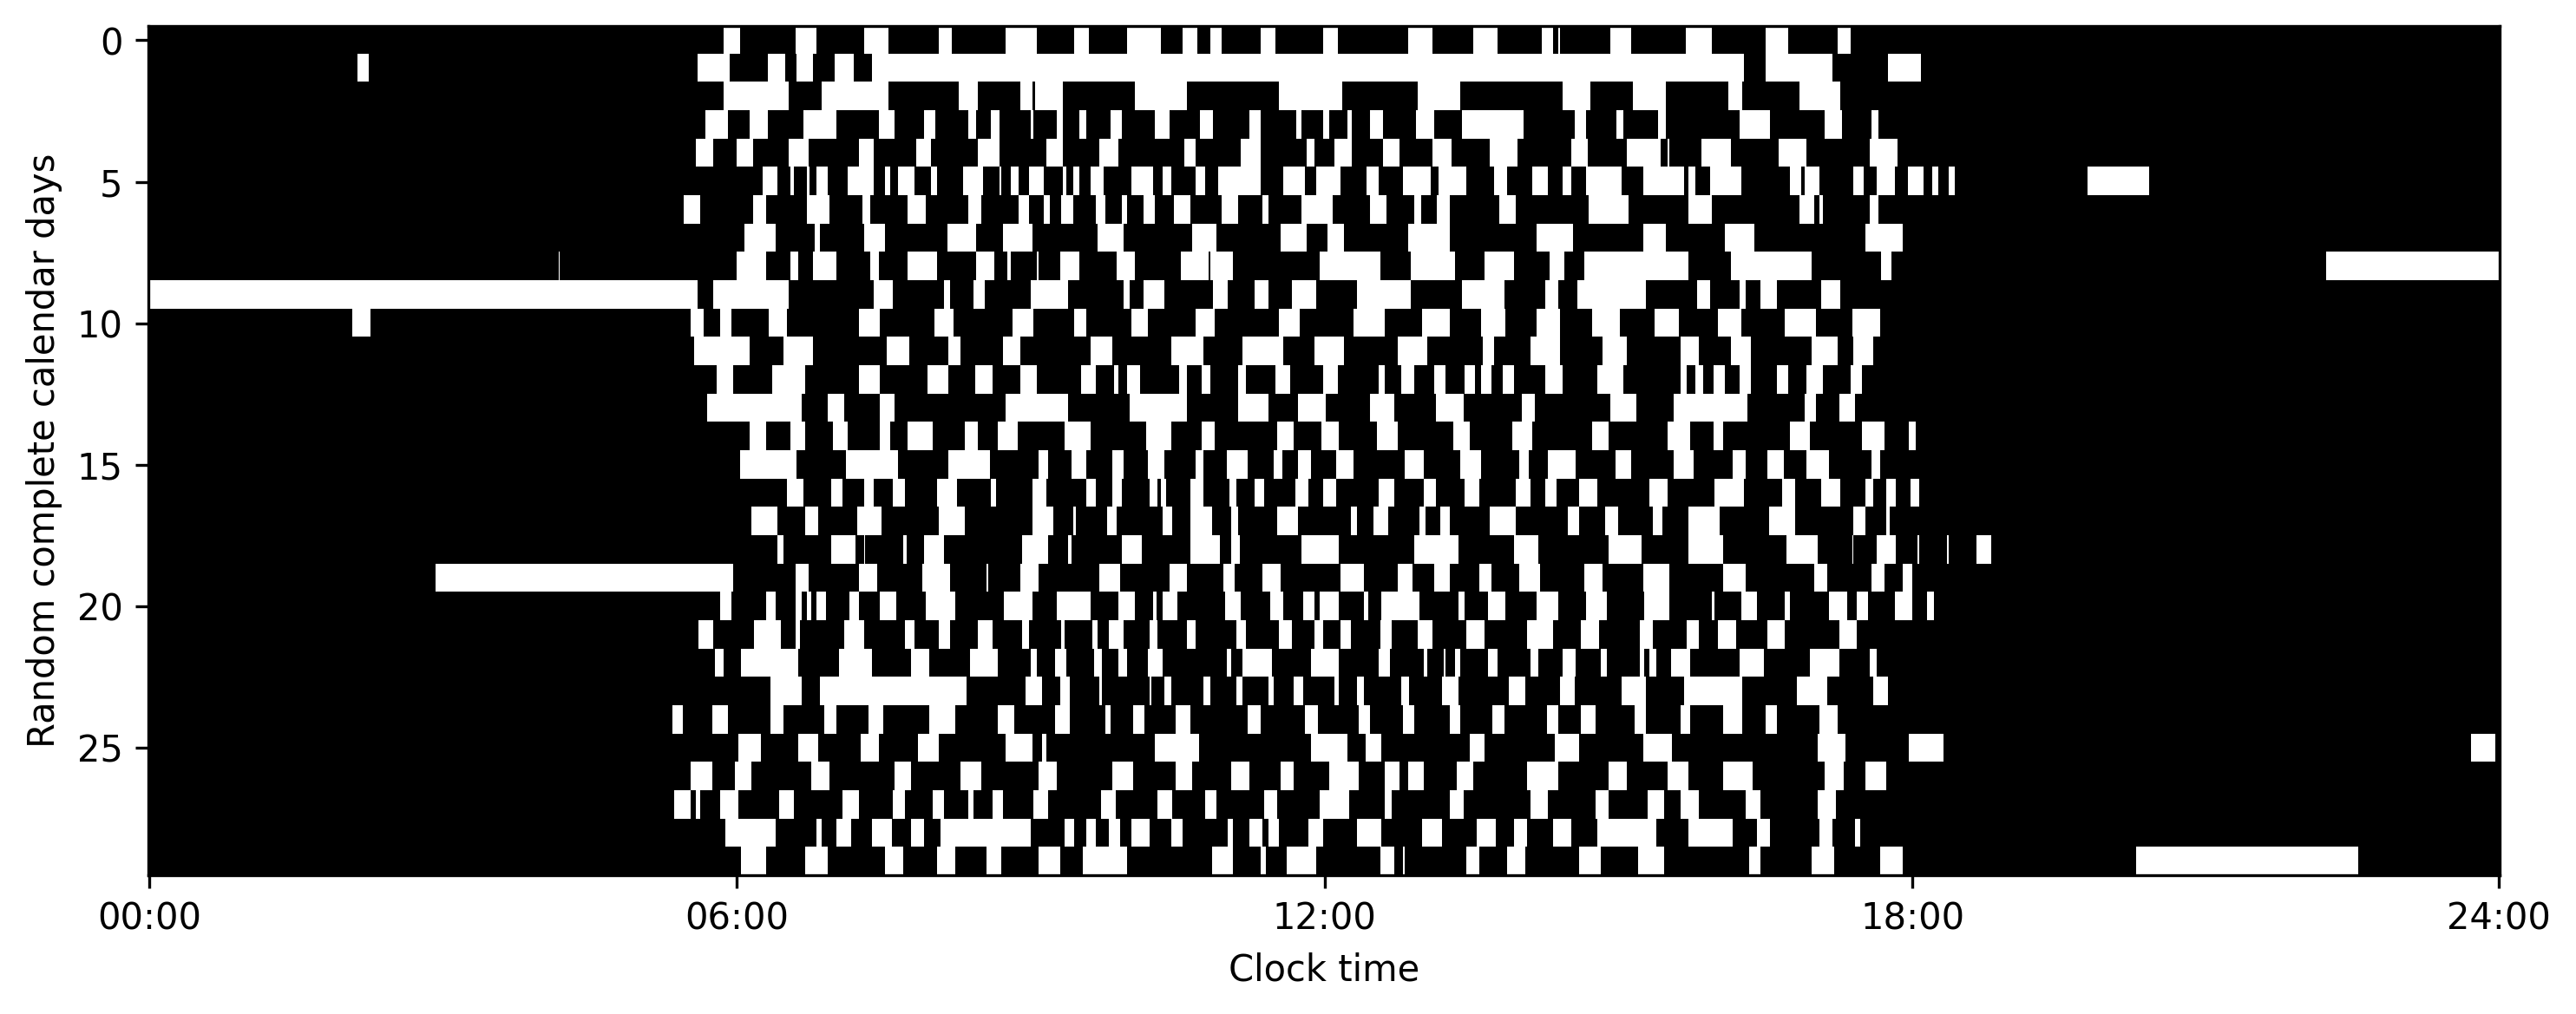

In [9]:
# ============================================================
# Observed binary rhythm raster
# 1 = On + Nocturnal
# 0 = Off
# ============================================================

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_raster = df_long[["Nest_ID", "calendar_date", "minute_of_day", "incubating"]].copy()

df_raster["minute_of_day"] = pd.to_numeric(df_raster["minute_of_day"], errors="coerce")
df_raster["incubating"] = pd.to_numeric(df_raster["incubating"], errors="coerce")

df_raster = df_raster[df_raster["minute_of_day"].between(0, 1439)].copy()

df_raster["minute_of_day"] = df_raster["minute_of_day"].astype(int)
df_raster["incubating"] = df_raster["incubating"].astype(int)

df_raster = (
    df_raster
    .sort_values(["Nest_ID", "calendar_date", "minute_of_day"])
    .drop_duplicates(subset=["Nest_ID", "calendar_date", "minute_of_day"], keep="first")
)

counts = (
    df_raster
    .groupby(["Nest_ID", "calendar_date"])["minute_of_day"]
    .nunique()
)

complete_keys = counts[counts == 1440].index

print("Complete calendar nest-days:", len(complete_keys))
print("Incomplete calendar nest-days:", (counts < 1440).sum())

df_complete = (
    df_raster
    .set_index(["Nest_ID", "calendar_date"])
    .loc[complete_keys]
    .reset_index()
)

matrix_df = df_complete.pivot(
    index=["Nest_ID", "calendar_date"],
    columns="minute_of_day",
    values="incubating"
)

matrix_df = matrix_df.reindex(columns=range(1440)).dropna()

print("Raster matrix shape:", matrix_df.shape)

n_days = 30
matrix_df_plot = matrix_df.sample(
    n=min(n_days, len(matrix_df)),
    random_state=42
)

matrix = matrix_df_plot.to_numpy()

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

ax.imshow(
    matrix,
    aspect="auto",
    cmap="binary",
    interpolation="nearest",
    vmin=0,
    vmax=1
)

ax.set_xlabel("Clock time")
ax.set_ylabel("Random complete calendar days")

ax.set_xticks([0, 360, 720, 1080, 1439])
ax.set_xticklabels(["00:00", "06:00", "12:00", "18:00", "24:00"])

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# Downsample to 2-minute resolution for GAMM speed
# ============================================================

df_long_2min = df_long[df_long["minute_of_day"] % 2 == 0].reset_index(drop=True)

print("df_long_2min shape:", df_long_2min.shape)

print(df_long_2min[
    [
        "archivo", "calendar_date", "dia_key", "Especie", "Estacion",
        "minute_of_day", "incubating",
        "Elevacion", "diaprox", "Huevo_Peso_g"
    ]
].head())

print("\nUnique nests:", df_long_2min["Nest_ID"].nunique())
print("Unique calendar nest-days:", df_long_2min["NestCalendarDay_ID"].nunique())
print("Unique stations:", df_long_2min["Estacion"].nunique())

print("\nStation counts:")
print(df_long_2min["Estacion"].value_counts())

df_long_2min shape: (100284, 28)
                                             archivo calendar_date  dia_key  \
0  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    2008-08-15        0   
1  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    2008-08-15        0   
2  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    2008-08-15        0   
3  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    2008-08-15        0   
4  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...    2008-08-15        0   

                    Especie   Estacion  minute_of_day  incubating  Elevacion  \
0  Myioborus_melanocephalus  San_Pedro              0           1     2263.0   
1  Myioborus_melanocephalus  San_Pedro              2           1     2263.0   
2  Myioborus_melanocephalus  San_Pedro              4           1     2263.0   
3  Myioborus_melanocephalus  San_Pedro              6           1     2263.0   
4  Myioborus_melanocephalus  San_Pedro              8           1     2263.0   

   diaprox 

In [11]:
# ============================================================
# Prepare clean GAMM dataframe
# ============================================================

cols_for_gamm = [
    "incubating",
    "minute_of_day",
    "Elevacion",
    "diaprox",
    "Huevo_Peso_g",
    "Especie",
    "Estacion",
    "Nest_ID",
    "NestCalendarDay_ID"
]

df_gamm = df_long_2min[cols_for_gamm].copy()

df_gamm["incubating"] = df_gamm["incubating"].astype(int)
df_gamm["minute_of_day"] = df_gamm["minute_of_day"].astype(int)

df_gamm["Elevacion"] = pd.to_numeric(df_gamm["Elevacion"], errors="coerce")
df_gamm["diaprox"] = pd.to_numeric(df_gamm["diaprox"], errors="coerce")
df_gamm["Huevo_Peso_g"] = pd.to_numeric(df_gamm["Huevo_Peso_g"], errors="coerce")

for col in ["Especie", "Estacion", "Nest_ID", "NestCalendarDay_ID"]:
    df_gamm[col] = df_gamm[col].astype(str)

df_gamm = df_gamm.dropna().reset_index(drop=True)

print(df_gamm.dtypes)
print(df_gamm.shape)

incubating              int64
minute_of_day           int64
Elevacion             float64
diaprox               float64
Huevo_Peso_g          float64
Especie                object
Estacion               object
Nest_ID                object
NestCalendarDay_ID     object
dtype: object
(100284, 9)


In [12]:
with localconverter(ro.default_converter + pandas2ri.converter):
    ro.globalenv["df_long"] = df_gamm

In [13]:
ro.r("""
library(mgcv)

df_long$Estacion <- as.factor(df_long$Estacion)
df_long$Nest_ID <- as.factor(df_long$Nest_ID)
df_long$NestCalendarDay_ID <- as.factor(df_long$NestCalendarDay_ID)
df_long$Especie <- as.factor(df_long$Especie)

cat("Rows:", nrow(df_long), "\\n")
cat("Nests:", length(unique(df_long$Nest_ID)), "\\n")
cat("Calendar nest-days:", length(unique(df_long$NestCalendarDay_ID)), "\\n")
cat("Species:", levels(df_long$Especie), "\\n")
cat("Stations:", levels(df_long$Estacion), "\\n")
""")

Rows: 100284 
Nests: 32 
Calendar nest-days: 145 
Species: Myioborus_melanocephalus Myioborus_miniatus 
Stations: San_Pedro Tatama Wayquecha 


In [14]:
ro.r("""
model_full <- bam(
  incubating ~
    Especie +
    Estacion +
    s(minute_of_day, bs = "cc", k = 20) +
    s(Elevacion, k = 6) +
    s(diaprox, k = 6) +
    s(Huevo_Peso_g, k = 5) +
    ti(minute_of_day, Elevacion, bs = c("cc", "tp"), k = c(20, 6)) +
    ti(minute_of_day, diaprox, bs = c("cc", "tp"), k = c(20, 6)) +
    s(Nest_ID, bs = "re"),

  data = df_long,
  family = binomial(link = "logit"),
  method = "fREML",
  discrete = TRUE
)

print(summary(model_full))
""")


Family: binomial 
Link function: logit 

Formula:
incubating ~ Especie + Estacion + s(minute_of_day, bs = "cc", 
    k = 20) + s(Elevacion, k = 6) + s(diaprox, k = 6) + s(Huevo_Peso_g, 
    k = 5) + ti(minute_of_day, Elevacion, bs = c("cc", "tp"), 
    k = c(20, 6)) + ti(minute_of_day, diaprox, bs = c("cc", "tp"), 
    k = c(20, 6)) + s(Nest_ID, bs = "re")

Parametric coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 3.9098     0.6747   5.795 6.85e-09 ***
EspecieMyioborus_miniatus  -0.1069     0.6048  -0.177    0.860    
EstacionTatama              0.0493     0.2705   0.182    0.855    
EstacionWayquecha           0.1932     1.6500   0.117    0.907    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                               edf Ref.df   Chi.sq  p-value    
s(minute_of_day)            16.888 18.000 2052.513  < 2e-16 ***
s(Elevacion)                 3.560  3.633

In [15]:
ro.r("""
model_no_eggmass <- bam(
  incubating ~
    Especie +
    Estacion +
    s(minute_of_day, bs = "cc", k = 20) +
    s(Elevacion, k = 6) +
    s(diaprox, k = 6) +
    ti(minute_of_day, Elevacion, bs = c("cc", "tp"), k = c(20, 6)) +
    ti(minute_of_day, diaprox, bs = c("cc", "tp"), k = c(20, 6)) +
    s(Nest_ID, bs = "re"),

  data = df_long,
  family = binomial(link = "logit"),
  method = "fREML",
  discrete = TRUE
)

print(summary(model_no_eggmass))
""")


Family: binomial 
Link function: logit 

Formula:
incubating ~ Especie + Estacion + s(minute_of_day, bs = "cc", 
    k = 20) + s(Elevacion, k = 6) + s(diaprox, k = 6) + ti(minute_of_day, 
    Elevacion, bs = c("cc", "tp"), k = c(20, 6)) + ti(minute_of_day, 
    diaprox, bs = c("cc", "tp"), k = c(20, 6)) + s(Nest_ID, bs = "re")

Parametric coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                4.00234    0.62014   6.454 1.09e-10 ***
EspecieMyioborus_miniatus -0.20662    0.52872  -0.391    0.696    
EstacionTatama             0.05814    0.26431   0.220    0.826    
EstacionWayquecha          0.10802    1.61499   0.067    0.947    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                               edf Ref.df  Chi.sq  p-value    
s(minute_of_day)            16.889 18.000 2048.92  < 2e-16 ***
s(Elevacion)                 3.586  3.660   48.66 6.01e-07 ***
s(diaprox)

In [16]:
ro.r("""
model_no_elev_interaction <- bam(
  incubating ~
    Especie +
    Estacion +
    s(minute_of_day, bs = "cc", k = 20) +
    s(Elevacion, k = 6) +
    s(diaprox, k = 6) +
    ti(minute_of_day, diaprox, bs = c("cc", "tp"), k = c(20, 6)) +
    s(Nest_ID, bs = "re"),

  data = df_long,
  family = binomial(link = "logit"),
  method = "fREML",
  discrete = TRUE
)

print(summary(model_no_elev_interaction))
""")


Family: binomial 
Link function: logit 

Formula:
incubating ~ Especie + Estacion + s(minute_of_day, bs = "cc", 
    k = 20) + s(Elevacion, k = 6) + s(diaprox, k = 6) + ti(minute_of_day, 
    diaprox, bs = c("cc", "tp"), k = c(20, 6)) + s(Nest_ID, bs = "re")

Parametric coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                3.03953    0.46438   6.545 5.94e-11 ***
EspecieMyioborus_miniatus -0.22071    0.46096  -0.479    0.632    
EstacionTatama            -0.04979    0.27290  -0.182    0.855    
EstacionWayquecha         -0.16624    0.79063  -0.210    0.833    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                             edf Ref.df   Chi.sq p-value    
s(minute_of_day)          16.814 18.000 2451.923  <2e-16 ***
s(Elevacion)               1.463  1.469    0.114   0.856    
s(diaprox)                 4.944  4.979  217.971  <2e-16 ***
ti(diaprox,minute_of_day)

In [17]:
ro.r("""
model_no_elev <- bam(
  incubating ~
    Especie +
    Estacion +
    s(minute_of_day, bs = "cc", k = 20) +
    s(diaprox, k = 6) +
    ti(minute_of_day, diaprox, bs = c("cc", "tp"), k = c(20, 6)) +
    s(Nest_ID, bs = "re"),

  data = df_long,
  family = binomial(link = "logit"),
  method = "fREML",
  discrete = TRUE
)

print(summary(model_no_elev))
""")


Family: binomial 
Link function: logit 

Formula:
incubating ~ Especie + Estacion + s(minute_of_day, bs = "cc", 
    k = 20) + s(diaprox, k = 6) + ti(minute_of_day, diaprox, 
    bs = c("cc", "tp"), k = c(20, 6)) + s(Nest_ID, bs = "re")

Parametric coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                3.03630    0.42046   7.221 5.15e-13 ***
EspecieMyioborus_miniatus -0.15474    0.41661  -0.371    0.710    
EstacionTatama            -0.10006    0.26059  -0.384    0.701    
EstacionWayquecha         -0.03361    0.41650  -0.081    0.936    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                             edf Ref.df Chi.sq p-value    
s(minute_of_day)          16.758 18.000 2441.6  <2e-16 ***
s(diaprox)                 4.944  4.979  217.5  <2e-16 ***
ti(diaprox,minute_of_day) 78.158 90.000  823.1  <2e-16 ***
s(Nest_ID)                27.428 29.000 1395.1  <2e-16 

In [18]:
ro.r("""
model_main_only <- bam(
  incubating ~
    Especie +
    Estacion +
    s(minute_of_day, bs = "cc", k = 20) +
    s(diaprox, k = 6) +
    s(Nest_ID, bs = "re"),

  data = df_long,
  family = binomial(link = "logit"),
  method = "fREML",
  discrete = TRUE
)

print(summary(model_main_only))
""")


Family: binomial 
Link function: logit 

Formula:
incubating ~ Especie + Estacion + s(minute_of_day, bs = "cc", 
    k = 20) + s(diaprox, k = 6) + s(Nest_ID, bs = "re")

Parametric coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)                2.15677    0.40678   5.302 1.15e-07 ***
EspecieMyioborus_miniatus -0.16812    0.41252  -0.408    0.684    
EstacionTatama            -0.09224    0.25801  -0.357    0.721    
EstacionWayquecha         -0.03477    0.41241  -0.084    0.933    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
                    edf Ref.df  Chi.sq p-value    
s(minute_of_day) 17.595 18.000 16601.9   0.816    
s(diaprox)        4.935  4.998   290.3  <2e-16 ***
s(Nest_ID)       27.435 28.000 17141.4  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =   0.18   Deviance explained = 21.1%
fREML = 1.321e+05  Scale est. = 1     

In [19]:
ro.r("""
model_comparison <- AIC(
  model_full,
  model_no_eggmass,
  model_no_elev_interaction,
  model_no_elev,
  model_main_only
)

print(model_comparison)

delta_AIC <- model_comparison$AIC - min(model_comparison$AIC)
model_comparison$delta_AIC <- delta_AIC

print(model_comparison[order(model_comparison$AIC), ])
""")

                                 df      AIC
model_full                205.63809 76798.48
model_no_eggmass          205.57910 76798.86
model_no_elev_interaction 132.81722 78624.24
model_no_elev             132.68914 78626.21
model_main_only            54.25205 79669.64
                                 df      AIC    delta_AIC
model_full                205.63809 76798.48    0.0000000
model_no_eggmass          205.57910 76798.86    0.3833029
model_no_elev_interaction 132.81722 78624.24 1825.7683982
model_no_elev             132.68914 78626.21 1827.7364371
model_main_only            54.25205 79669.64 2871.1674277


In [20]:
ro.r("""
gam.check(model_no_eggmass)
""")


Method: fREML   Optimizer: perf chol
$grad
[1] 1.678731e-06 5.418849e-07 9.626312e-08 1.651459e-06 1.789293e-05
[6] 1.575611e-06 7.267060e-06 3.394227e-07

$hess
             [,1]         [,2]         [,3]        [,4]        [,5]        [,6]
[1,]  6.738232705 -0.003410748 -0.024304747  0.07398967 -1.62083912 -0.38352517
[2,] -0.003410748  1.411808310 -0.001933247 -0.21941256 -0.24985951 -0.01302451
[3,] -0.024304747 -0.001933247  1.876922044 -0.01749629 -0.02909163 -0.51759567
[4,]  0.073989672 -0.219412555 -0.017496293  3.05554146 -0.10586347 -0.08692525
[5,] -1.620839116 -0.249859507 -0.029091626 -0.10586347 10.43661470 -0.22407213
[6,] -0.383525166 -0.013024510 -0.517595671 -0.08692525 -0.22407213 10.41811899
[7,] -1.563734773 -0.007947975 -0.420978117 -0.10109280 -0.22247231 -2.03505410
[8,] -0.003065322 -0.124325963 -0.026367024 -0.07854159 -0.12531378 -0.11728022
             [,7]         [,8]
[1,] -1.563734773 -0.003065322
[2,] -0.007947975 -0.124325963
[3,] -0.420978117 -0.026

In [21]:
ro.r("""
concurvity(model_no_eggmass, full = TRUE)
""")

1.000000,1.000000,1.000000,...,1.000000,0.206192,0.397722


In [22]:
ro.r("""
sink("data/GAMM_preferred_model_no_eggmass_summary.txt")

cat("MODEL COMPARISON\\n")
print(model_comparison[order(model_comparison$AIC), ])

cat("\\n\\nPREFERRED MODEL: model_no_eggmass\\n")
print(summary(model_no_eggmass))

cat("\\n\\nGAM CHECK\\n")
print(gam.check(model_no_eggmass))

cat("\\n\\nCONCURVITY\\n")
print(concurvity(model_no_eggmass, full = TRUE))

sink()
""")

Mejor modelo model_no_eggmass

In [23]:
ro.r("""
library(mgcv)

# -----------------------------
# Reference values
# -----------------------------
ref_species <- names(sort(table(df_long$Especie), decreasing = TRUE))[1]
ref_station <- names(sort(table(df_long$Estacion), decreasing = TRUE))[1]
ref_nest <- levels(df_long$Nest_ID)[1]

ref_elev <- median(df_long$Elevacion, na.rm = TRUE)
ref_diaprox <- median(df_long$diaprox, na.rm = TRUE)

# Sequences for surfaces
minute_seq <- 0:1439
elev_seq <- seq(
  min(df_long$Elevacion, na.rm = TRUE),
  max(df_long$Elevacion, na.rm = TRUE),
  length.out = 60
)
diaprox_seq <- seq(
  min(df_long$diaprox, na.rm = TRUE),
  max(df_long$diaprox, na.rm = TRUE),
  length.out = 50
)

# -----------------------------
# Surface 1: minute_of_day x diaprox
# Elevation fixed at median
# -----------------------------
pred_surface_diaprox <- expand.grid(
  minute_of_day = minute_seq,
  diaprox = diaprox_seq
)

pred_surface_diaprox$Elevacion <- ref_elev
pred_surface_diaprox$Especie <- factor(ref_species, levels = levels(df_long$Especie))
pred_surface_diaprox$Estacion <- factor(ref_station, levels = levels(df_long$Estacion))
pred_surface_diaprox$Nest_ID <- factor(ref_nest, levels = levels(df_long$Nest_ID))

pred_surface_diaprox$fit <- predict(
  model_no_eggmass,
  newdata = pred_surface_diaprox,
  type = "response",
  exclude = "s(Nest_ID)"
)

# -----------------------------
# Surface 2: minute_of_day x Elevacion
# Egg age fixed at median
# -----------------------------
pred_surface_elev <- expand.grid(
  minute_of_day = minute_seq,
  Elevacion = elev_seq
)

pred_surface_elev$diaprox <- ref_diaprox
pred_surface_elev$Especie <- factor(ref_species, levels = levels(df_long$Especie))
pred_surface_elev$Estacion <- factor(ref_station, levels = levels(df_long$Estacion))
pred_surface_elev$Nest_ID <- factor(ref_nest, levels = levels(df_long$Nest_ID))

pred_surface_elev$fit <- predict(
  model_no_eggmass,
  newdata = pred_surface_elev,
  type = "response",
  exclude = "s(Nest_ID)"
)

# -----------------------------
# Line plot 1: 3 egg-age levels
# -----------------------------
dia_levels <- as.numeric(quantile(df_long$diaprox, probs = c(0.1, 0.5, 0.9), na.rm = TRUE))
dia_labels <- c("Low egg age", "Mid egg age", "High egg age")

pred_lines_diaprox <- expand.grid(
  minute_of_day = minute_seq,
  diaprox = dia_levels
)

pred_lines_diaprox$Elevacion <- ref_elev
pred_lines_diaprox$Especie <- factor(ref_species, levels = levels(df_long$Especie))
pred_lines_diaprox$Estacion <- factor(ref_station, levels = levels(df_long$Estacion))
pred_lines_diaprox$Nest_ID <- factor(ref_nest, levels = levels(df_long$Nest_ID))

p_dia <- predict(
  model_no_eggmass,
  newdata = pred_lines_diaprox,
  type = "link",
  se.fit = TRUE,
  exclude = "s(Nest_ID)"
)

pred_lines_diaprox$fit <- plogis(p_dia$fit)
pred_lines_diaprox$lower <- plogis(p_dia$fit - 1.96 * p_dia$se.fit)
pred_lines_diaprox$upper <- plogis(p_dia$fit + 1.96 * p_dia$se.fit)
pred_lines_diaprox$group <- factor(
  rep(dia_labels, each = length(minute_seq)),
  levels = dia_labels
)

# -----------------------------
# Line plot 2: 3 elevation levels
# -----------------------------
elev_levels <- as.numeric(quantile(df_long$Elevacion, probs = c(0.1, 0.5, 0.9), na.rm = TRUE))
elev_labels <- c("Low elevation", "Mid elevation", "High elevation")

pred_lines_elev <- expand.grid(
  minute_of_day = minute_seq,
  Elevacion = elev_levels
)

pred_lines_elev$diaprox <- ref_diaprox
pred_lines_elev$Especie <- factor(ref_species, levels = levels(df_long$Especie))
pred_lines_elev$Estacion <- factor(ref_station, levels = levels(df_long$Estacion))
pred_lines_elev$Nest_ID <- factor(ref_nest, levels = levels(df_long$Nest_ID))

p_elev <- predict(
  model_no_eggmass,
  newdata = pred_lines_elev,
  type = "link",
  se.fit = TRUE,
  exclude = "s(Nest_ID)"
)

pred_lines_elev$fit <- plogis(p_elev$fit)
pred_lines_elev$lower <- plogis(p_elev$fit - 1.96 * p_elev$se.fit)
pred_lines_elev$upper <- plogis(p_elev$fit + 1.96 * p_elev$se.fit)
pred_lines_elev$group <- factor(
  rep(elev_labels, each = length(minute_seq)),
  levels = elev_labels
)
""")

In [24]:
with localconverter(ro.default_converter + pandas2ri.converter):
    pred_surface_diaprox = ro.conversion.rpy2py(ro.r("pred_surface_diaprox"))
    pred_surface_elev = ro.conversion.rpy2py(ro.r("pred_surface_elev"))
    pred_lines_diaprox = ro.conversion.rpy2py(ro.r("pred_lines_diaprox"))
    pred_lines_elev = ro.conversion.rpy2py(ro.r("pred_lines_elev"))

print(pred_surface_diaprox.head())
print(pred_surface_elev.head())
print(pred_lines_diaprox.head())
print(pred_lines_elev.head())

   minute_of_day  diaprox  Elevacion             Especie Estacion  \
1              0      1.0     1684.0  Myioborus_miniatus   Tatama   
2              1      1.0     1684.0  Myioborus_miniatus   Tatama   
3              2      1.0     1684.0  Myioborus_miniatus   Tatama   
4              3      1.0     1684.0  Myioborus_miniatus   Tatama   
5              4      1.0     1684.0  Myioborus_miniatus   Tatama   

                                             Nest_ID       fit  
1  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  0.999994  
2  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  0.999993  
3  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  0.999993  
4  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  0.999992  
5  Myioborus_melanocephalus_TU1a_DOR08_NEST_proce...  0.999990  
   minute_of_day  Elevacion  diaprox             Especie Estacion  \
1              0     1356.0      6.0  Myioborus_miniatus   Tatama   
2              1     1356.0      6.0  Myioborus_miniatus 

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def plot_surface_heatmap(pred_df, y_col, ylabel, outpath):
    heat_df = pred_df.pivot(index=y_col, columns="minute_of_day", values="fit")
    heat_df = heat_df.sort_index()

    Z = heat_df.values
    x1 = heat_df.columns.values
    y1 = heat_df.index.values

    X1, Y1 = np.meshgrid(x1, y1)

    center = np.percentile(Z, 30)
    norm = TwoSlopeNorm(vmin=0, vcenter=center, vmax=1)

    plt.figure(figsize=(12, 5), dpi=300)

    im = plt.imshow(
        Z,
        aspect='auto',
        origin='lower',
        cmap='seismic',
        interpolation='bilinear',
        norm=norm,
        extent=[x1.min(), x1.max(), y1.min(), y1.max()]
    )

    contours = plt.contour(
        X1,
        Y1,
        Z,
        colors='black',
        linewidths=0.4
    )

    plt.clabel(contours, inline=True, fontsize=9, fmt="%.2f")

    # Ticks del eje x como reloj
    plt.xticks(
        [0, 360, 720, 1080, 1439],
        ["00:00", "06:00", "12:00", "18:00", "24:00"],
        fontsize=12
    )

    plt.xlabel("Time of day", fontsize=14)
    plt.ylabel(ylabel, fontsize=14)

    cbar = plt.colorbar(im)
    cbar.set_label("Probability of incubation", fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    cbar.set_ticks([0, center, 1])
    cbar.set_ticklabels(["Low", "Mid", "High"])

    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(0.8)

    ax.tick_params(axis='both', colors='black', labelsize=12)
    ax.grid(axis='y', alpha=0.2)

    plt.tight_layout()
    plt.savefig(outpath, dpi=300, transparent=True, bbox_inches="tight")
    plt.show()

### Time of day × Egg age

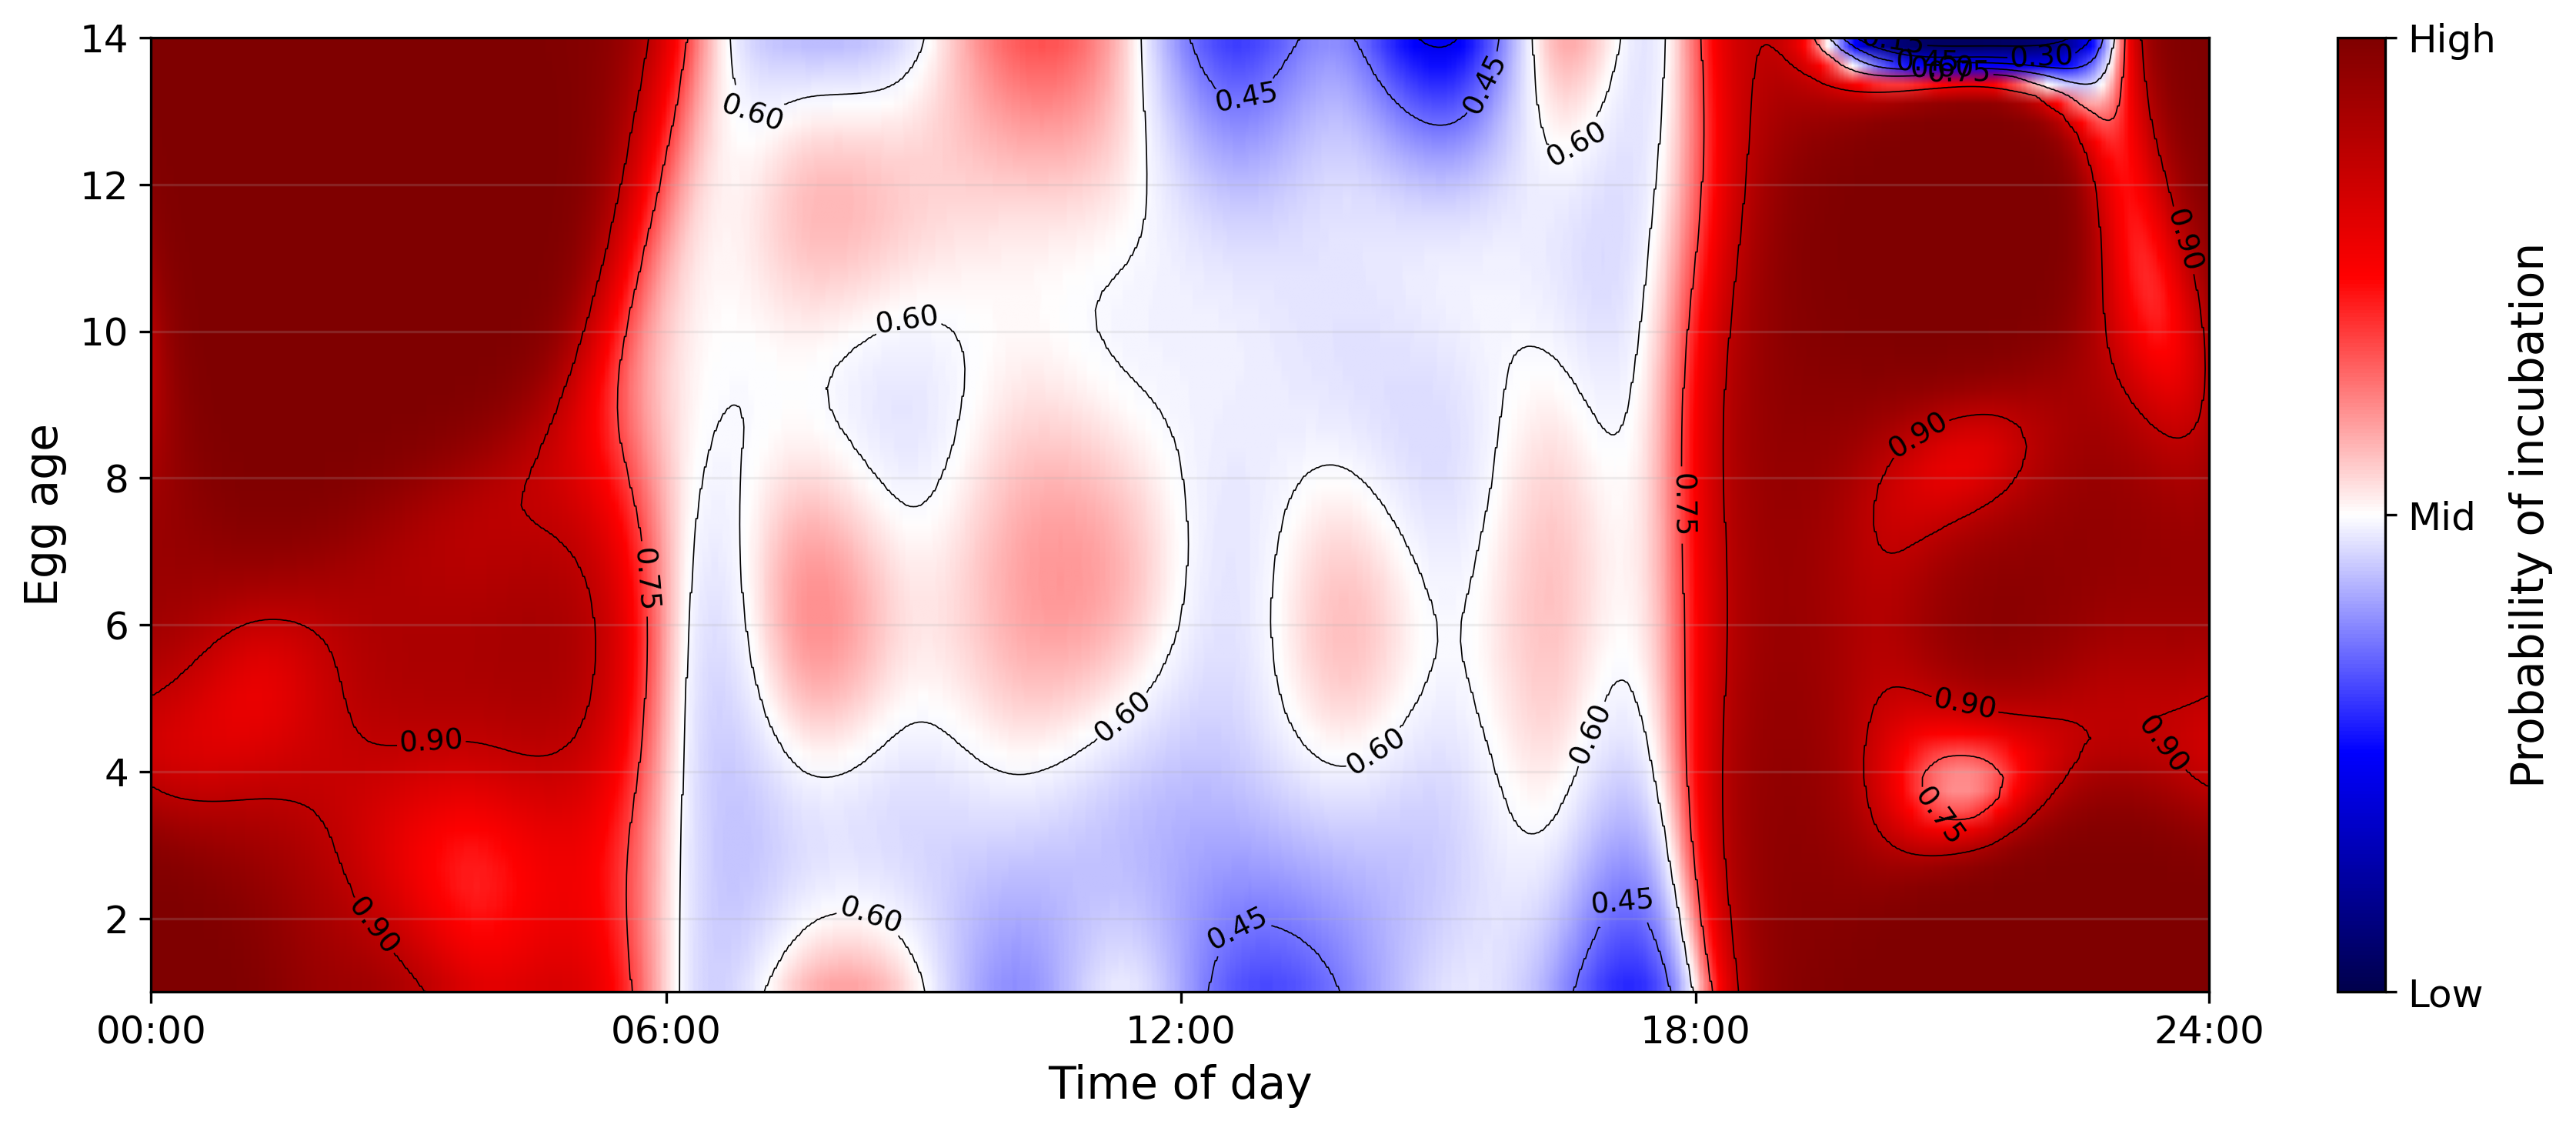

In [26]:
plot_surface_heatmap(
    pred_surface_diaprox,
    y_col="diaprox",
    ylabel="Egg age",
    outpath="Figures/GAMM_surface_time_x_eggage.png"
)

### ### Time of day × Egg age

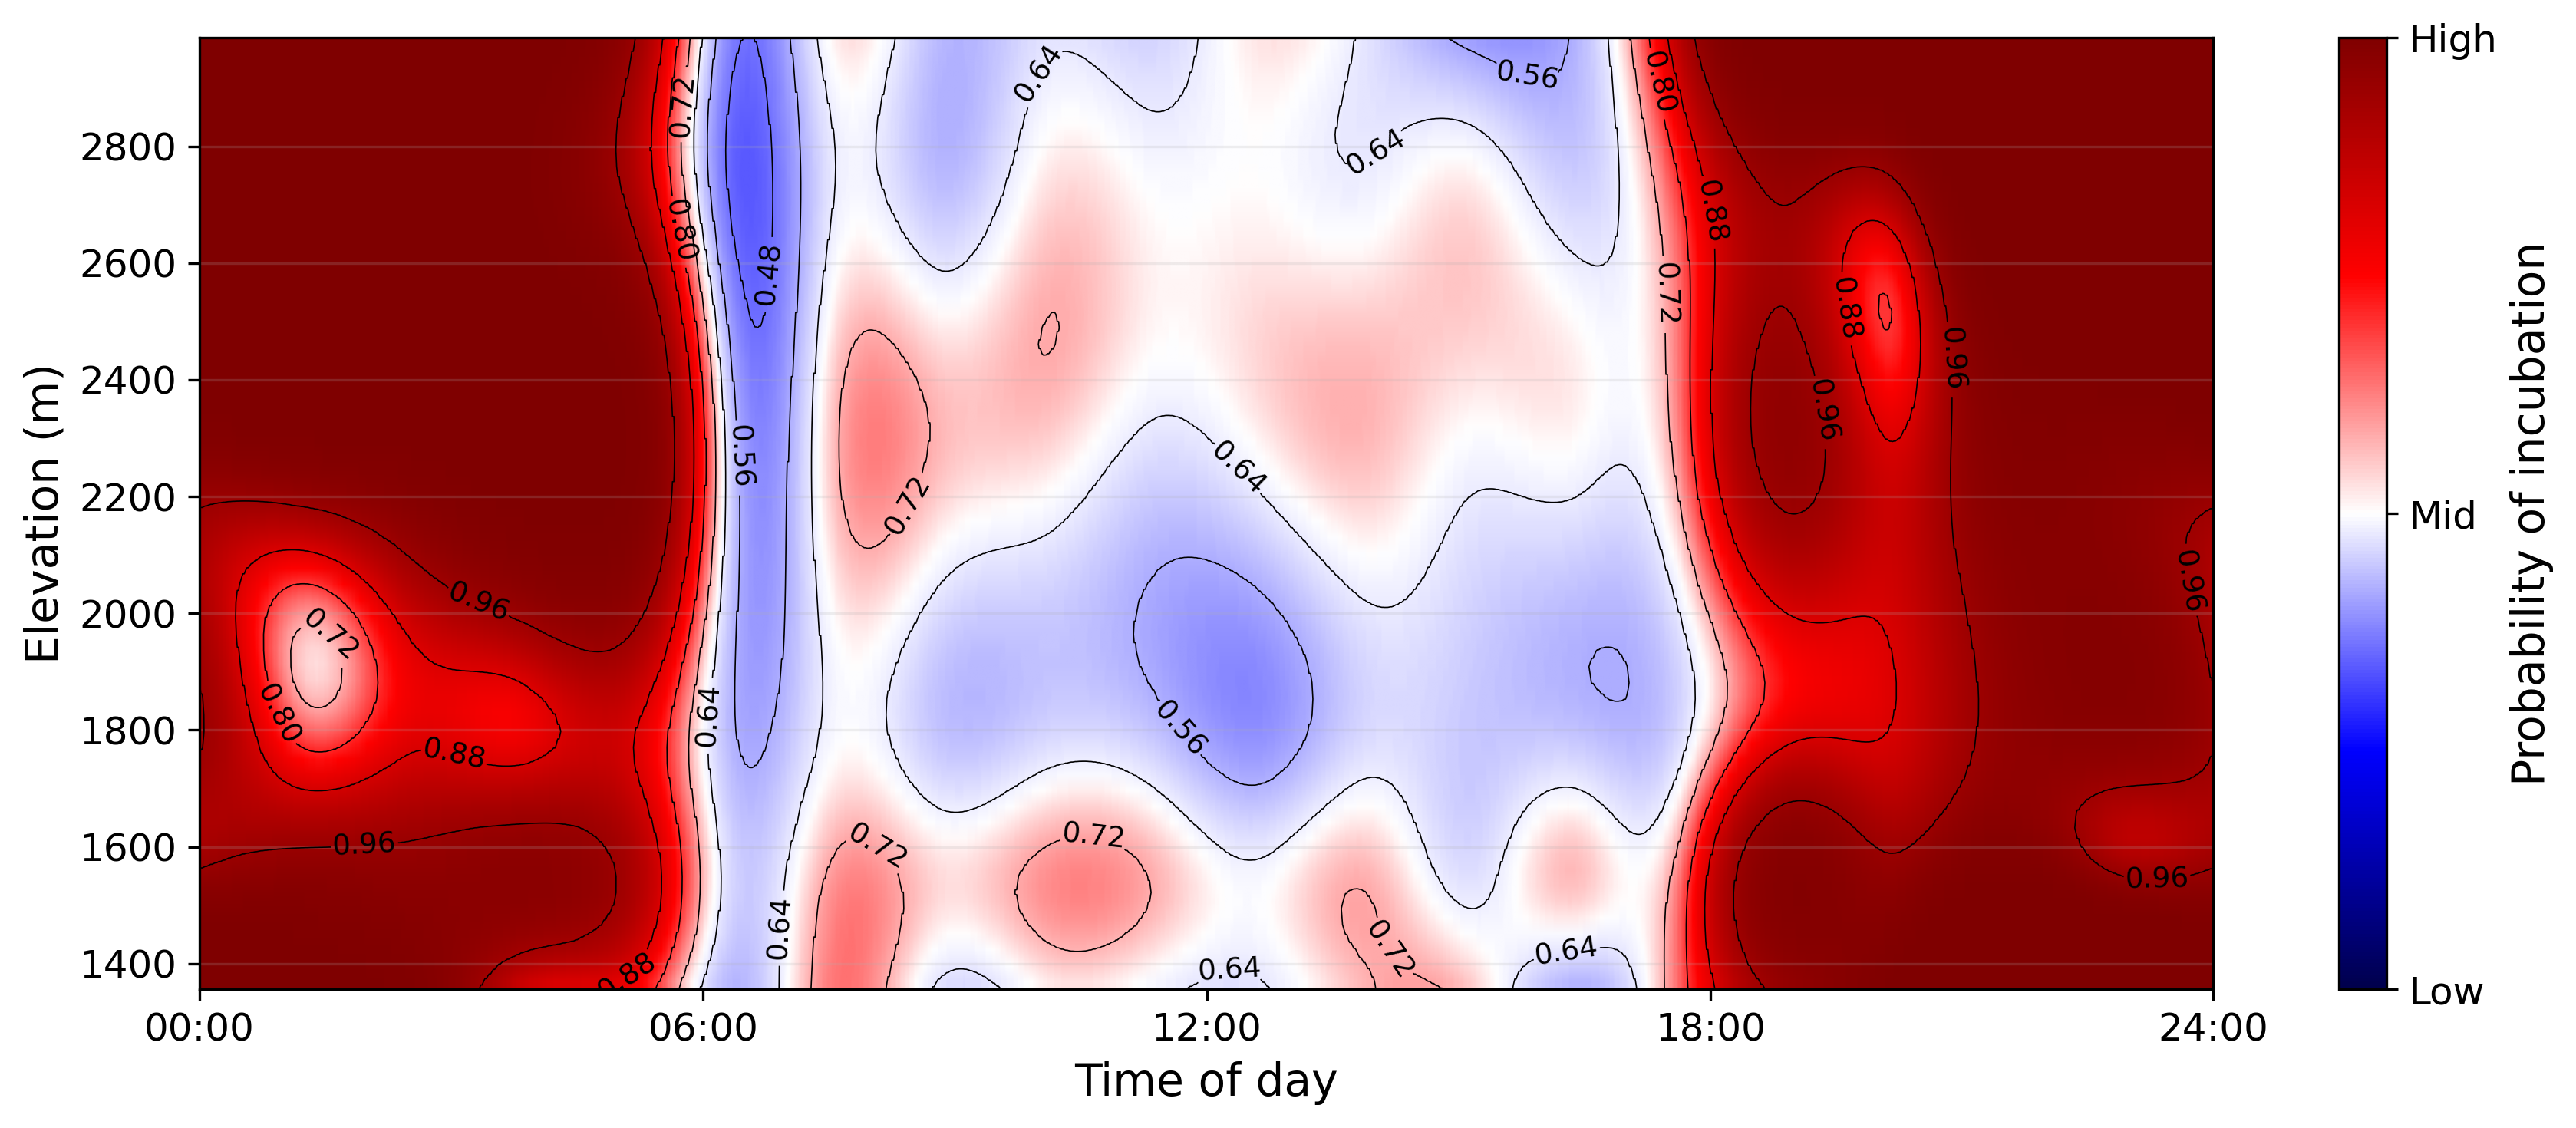

In [27]:
plot_surface_heatmap(
    pred_surface_elev,
    y_col="Elevacion",
    ylabel="Elevation (m)",
    outpath="Figures/GAMM_surface_time_x_elevation.png"
)

In [28]:
ro.r("""
# -----------------------------
# Line plot 1: 5 egg-age levels
# -----------------------------
dia_levels <- as.numeric(quantile(
  df_long$diaprox,
  probs = c(0.1, 0.3, 0.5, 0.7, 0.9),
  na.rm = TRUE
))

dia_labels <- paste0("Egg age = ", round(dia_levels, 1))

pred_lines_diaprox <- expand.grid(
  minute_of_day = minute_seq,
  diaprox = dia_levels
)

pred_lines_diaprox$Elevacion <- ref_elev
pred_lines_diaprox$Especie <- factor(ref_species, levels = levels(df_long$Especie))
pred_lines_diaprox$Estacion <- factor(ref_station, levels = levels(df_long$Estacion))
pred_lines_diaprox$Nest_ID <- factor(ref_nest, levels = levels(df_long$Nest_ID))

p_dia <- predict(
  model_no_eggmass,
  newdata = pred_lines_diaprox,
  type = "link",
  se.fit = TRUE,
  exclude = "s(Nest_ID)"
)

pred_lines_diaprox$fit <- plogis(p_dia$fit)
pred_lines_diaprox$lower <- plogis(p_dia$fit - 1.96 * p_dia$se.fit)
pred_lines_diaprox$upper <- plogis(p_dia$fit + 1.96 * p_dia$se.fit)

pred_lines_diaprox$group <- factor(
  rep(dia_labels, each = length(minute_seq)),
  levels = dia_labels
)
""")

In [29]:
ro.r("""
# -----------------------------
# Line plot 2: 5 elevation levels
# -----------------------------
elev_levels <- as.numeric(quantile(
  df_long$Elevacion,
  probs = c(0.1, 0.3, 0.5, 0.7, 0.9),
  na.rm = TRUE
))

elev_labels <- paste0("Elevation = ", round(elev_levels, 0), " m")

pred_lines_elev <- expand.grid(
  minute_of_day = minute_seq,
  Elevacion = elev_levels
)

pred_lines_elev$diaprox <- ref_diaprox
pred_lines_elev$Especie <- factor(ref_species, levels = levels(df_long$Especie))
pred_lines_elev$Estacion <- factor(ref_station, levels = levels(df_long$Estacion))
pred_lines_elev$Nest_ID <- factor(ref_nest, levels = levels(df_long$Nest_ID))

p_elev <- predict(
  model_no_eggmass,
  newdata = pred_lines_elev,
  type = "link",
  se.fit = TRUE,
  exclude = "s(Nest_ID)"
)

pred_lines_elev$fit <- plogis(p_elev$fit)
pred_lines_elev$lower <- plogis(p_elev$fit - 1.96 * p_elev$se.fit)
pred_lines_elev$upper <- plogis(p_elev$fit + 1.96 * p_elev$se.fit)

pred_lines_elev$group <- factor(
  rep(elev_labels, each = length(minute_seq)),
  levels = elev_labels
)
""")

### Curvas para distintos egg ages

In [30]:
with localconverter(ro.default_converter + pandas2ri.converter):
    pred_lines_diaprox = ro.conversion.rpy2py(ro.r("pred_lines_diaprox"))
    pred_lines_elev = ro.conversion.rpy2py(ro.r("pred_lines_elev"))

In [31]:
def plot_line_predictions(pred_df, group_col, outpath, ylabel_legend):
    fig, ax = plt.subplots(figsize=(12, 5), dpi=300)

    groups = pred_df[group_col].unique()

    for group in groups:
        sub = pred_df[pred_df[group_col] == group].sort_values("minute_of_day")

        ax.plot(
            sub["minute_of_day"],
            sub["fit"],
            linewidth=2,
            label=str(group)
        )

        ax.fill_between(
            sub["minute_of_day"],
            sub["lower"],
            sub["upper"],
            alpha=0.15
        )

    ax.set_xticks([0, 360, 720, 1080, 1439])
    ax.set_xticklabels(["00:00", "06:00", "12:00", "18:00", "24:00"])

    ax.set_xlabel("Time of day", fontsize=14)
    ax.set_ylabel("Probability of incubation", fontsize=14)
    ax.set_ylim(0, 1)

    ax.legend(
        title=ylabel_legend,
        frameon=False,
        fontsize=11,
        title_fontsize=12,
        loc="best"
    )

    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

    ax.tick_params(axis="both", colors="black", labelsize=12)
    ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig(outpath, dpi=300, transparent=True, bbox_inches="tight")
    plt.show()

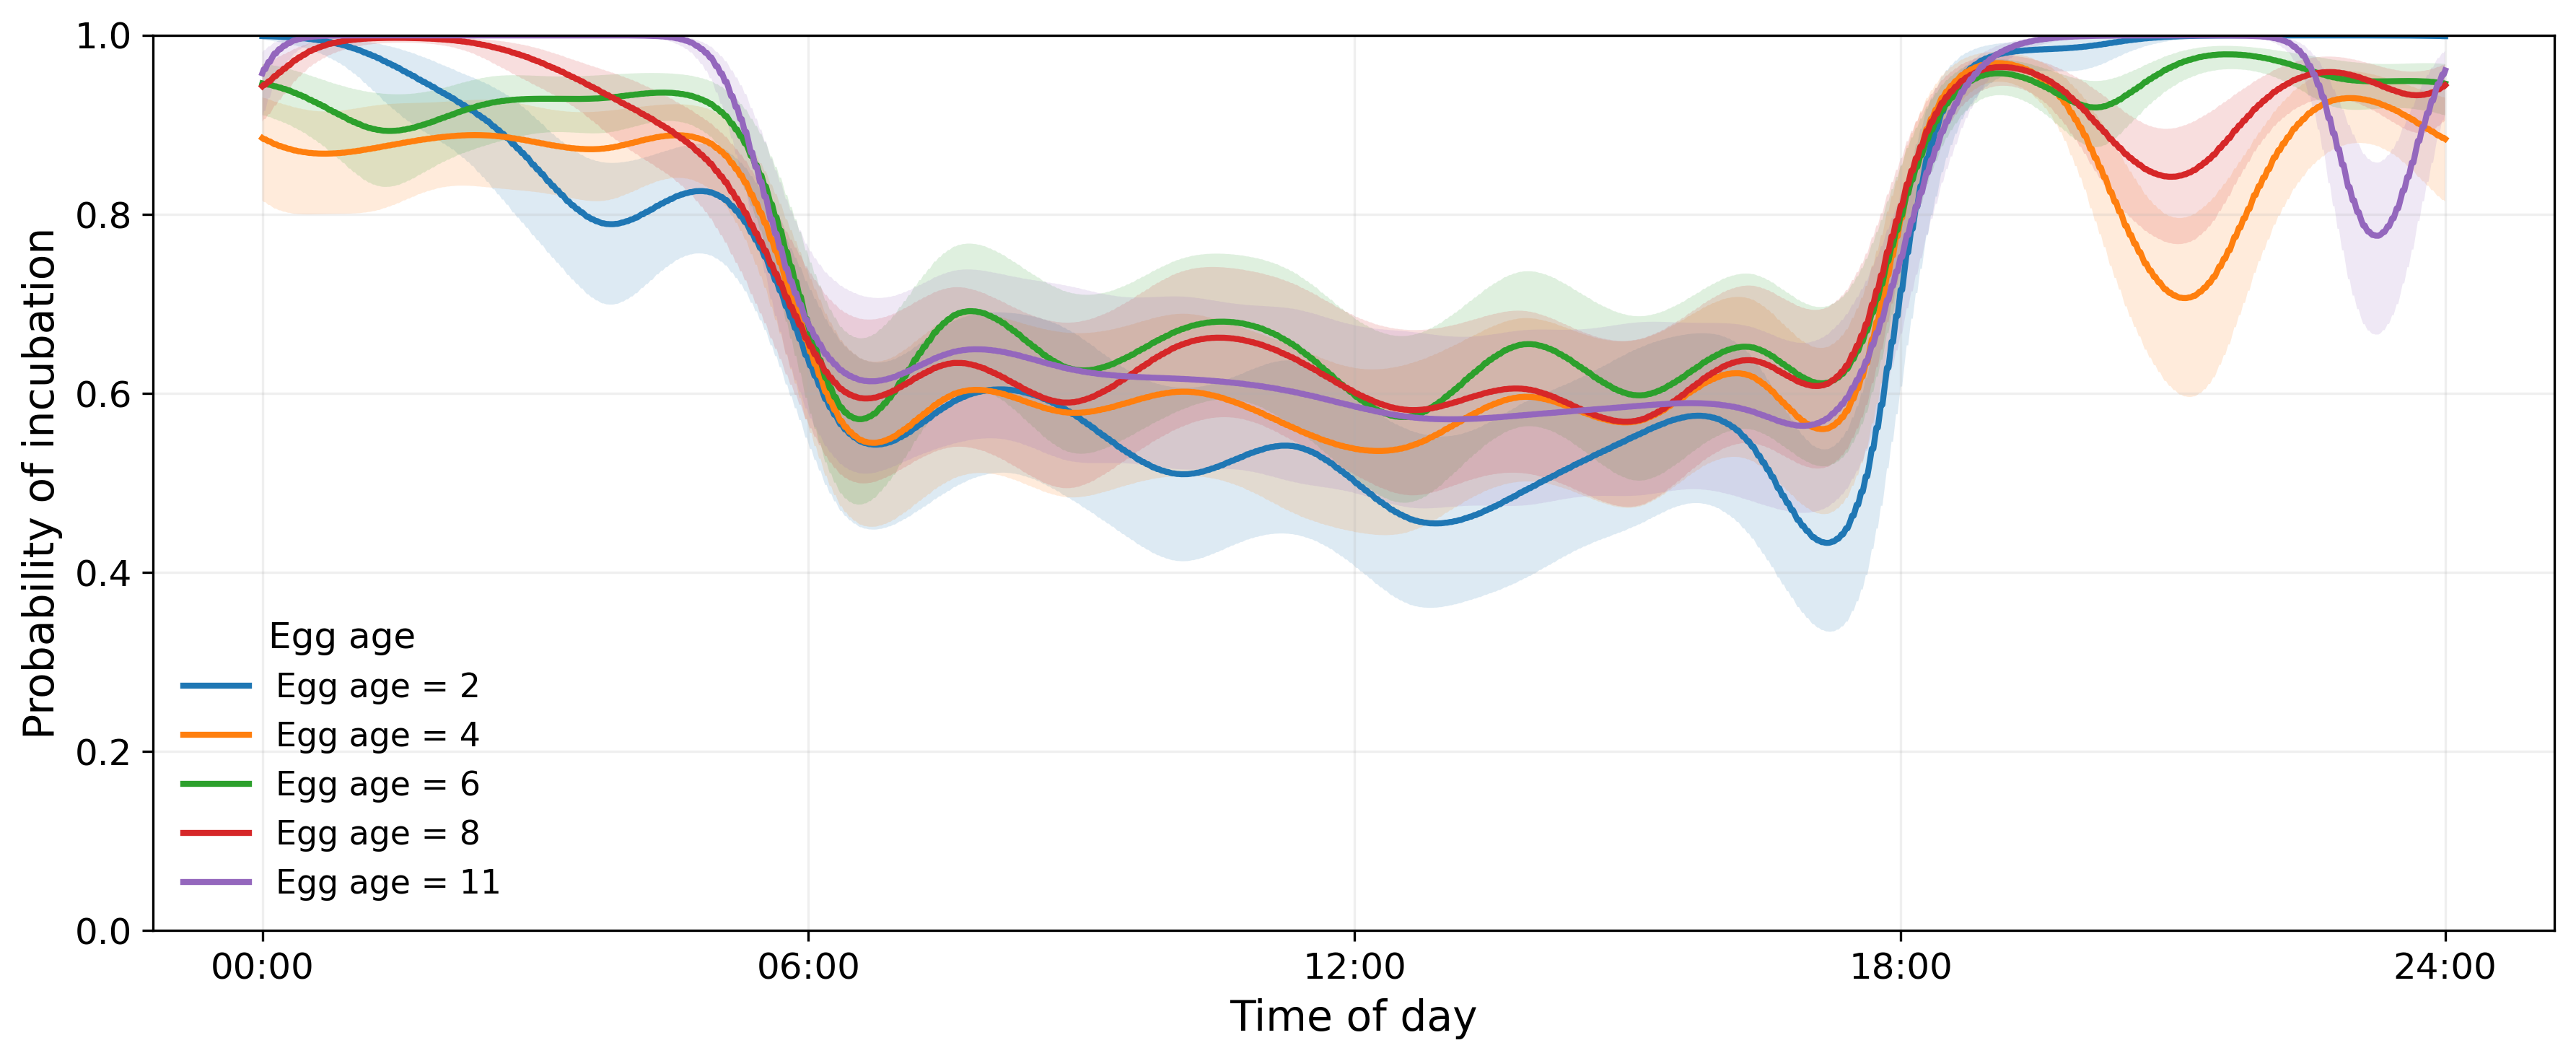

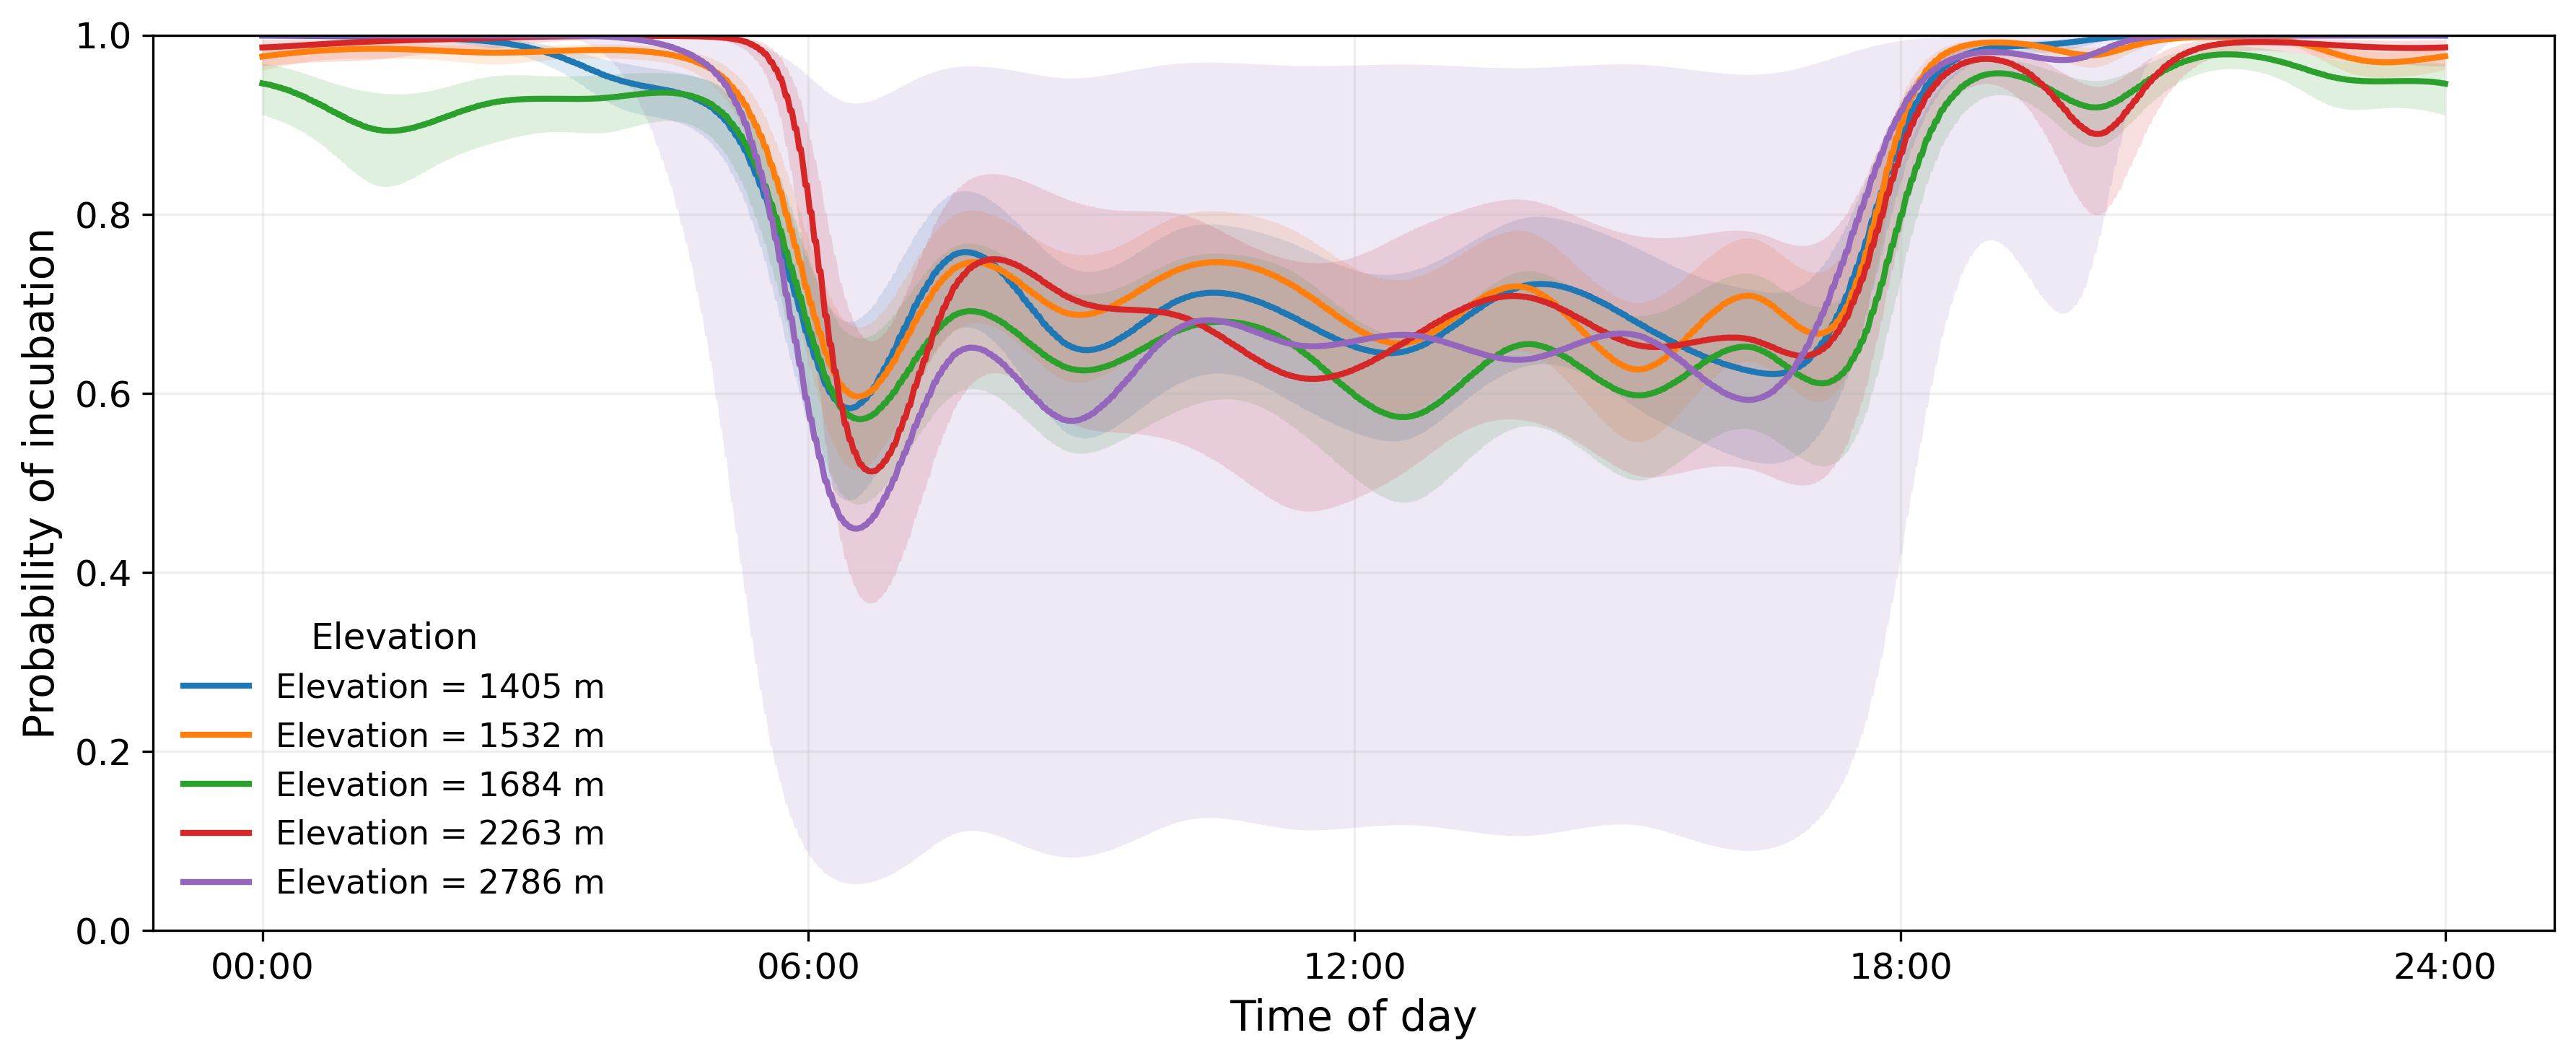

In [32]:
### Curves for different egg ages
plot_line_predictions(
    pred_lines_diaprox,
    group_col="group",
    outpath="Figures/GAMM_lines_eggage.png",
    ylabel_legend="Egg age"
)

### Curves for different elevations
plot_line_predictions(
    pred_lines_elev,
    group_col="group",
    outpath="Figures/GAMM_lines_elevation.png",
    ylabel_legend="Elevation"
)

In [33]:
ro.r("""
# ============================================================
# Random-effect diagnostics for preferred GAMM
# model_no_eggmass: s(Nest_ID, bs = "re")
# ============================================================

library(mgcv)

# Extract smooth table
smry <- summary(model_no_eggmass)

cat("\\nSmooth terms:\\n")
print(smry$s.table)

cat("\\nRandom effect term: s(Nest_ID)\\n")
print(smry$s.table[grep("Nest_ID", rownames(smry$s.table)), , drop = FALSE])

# Variance components / smoothing-parameter-based random effect SD
cat("\\nVariance components from gam.vcomp():\\n")
vc <- gam.vcomp(model_no_eggmass)
print(vc)

# Extract coefficients for random-effect levels
coef_all <- coef(model_no_eggmass)

re_idx <- grep("^s\\\\(Nest_ID\\\\)", names(coef_all))
re_values <- coef_all[re_idx]

# Clean names
re_df <- data.frame(
  term = names(re_values),
  re_logit = as.numeric(re_values)
)

re_df$Nest_ID <- gsub("^s\\\\(Nest_ID\\\\)\\\\.", "", re_df$term)

# Convert random intercept effect from logit scale to odds multiplier
re_df$odds_multiplier <- exp(re_df$re_logit)

# Rank individuals/nests
re_df <- re_df[order(re_df$re_logit), ]

cat("\\nRandom-effect summary on logit scale:\\n")
print(summary(re_df$re_logit))

cat("\\nRandom-effect SD on logit scale:\\n")
print(sd(re_df$re_logit))

cat("\\nMost negative nest-level deviations:\\n")
print(head(re_df, 10))

cat("\\nMost positive nest-level deviations:\\n")
print(tail(re_df, 10))

write.csv(
  re_df,
  "data/random_effects_Nest_ID_model_no_eggmass.csv",
  row.names = FALSE
)
""")


Smooth terms:
                                  edf    Ref.df     Chi.sq      p-value
s(minute_of_day)            16.888961 18.000000 2048.91749 0.000000e+00
s(Elevacion)                 3.585541  3.660269   48.66337 6.014378e-07
s(diaprox)                   4.947357  4.978608  274.57424 0.000000e+00
ti(Elevacion,minute_of_day) 70.753434 90.000000 1193.86069 0.000000e+00
ti(diaprox,minute_of_day)   79.440790 90.000000  761.06033 0.000000e+00
s(Nest_ID)                  23.616181 29.000000 1263.99583 0.000000e+00

Random effect term: s(Nest_ID)
                edf Ref.df   Chi.sq p-value
s(Nest_ID) 23.61618     29 1263.996       0

Variance components from gam.vcomp():

Standard deviations and 0.95 confidence intervals:

                                  std.dev        lower        upper
s(minute_of_day)             0.0043114239 0.0029079171 0.0063923336
s(Elevacion)                 0.0003238187 0.0001409305 0.0007440441
s(diaprox)                   0.8651655970 0.4185952337 1.78815105

In [34]:
with localconverter(ro.default_converter + pandas2ri.converter):
    re_df = ro.conversion.rpy2py(ro.r("re_df"))

re_df.head()

,term,re_logit,Nest_ID,odds_multiplier
24,s(Nest_ID).24,-1.247515,24,0.287218
20,s(Nest_ID).20,-1.121332,20,0.325845
16,s(Nest_ID).16,-0.909471,16,0.402737
11,s(Nest_ID).11,-0.380331,11,0.683635
10,s(Nest_ID).10,-0.335305,10,0.715120


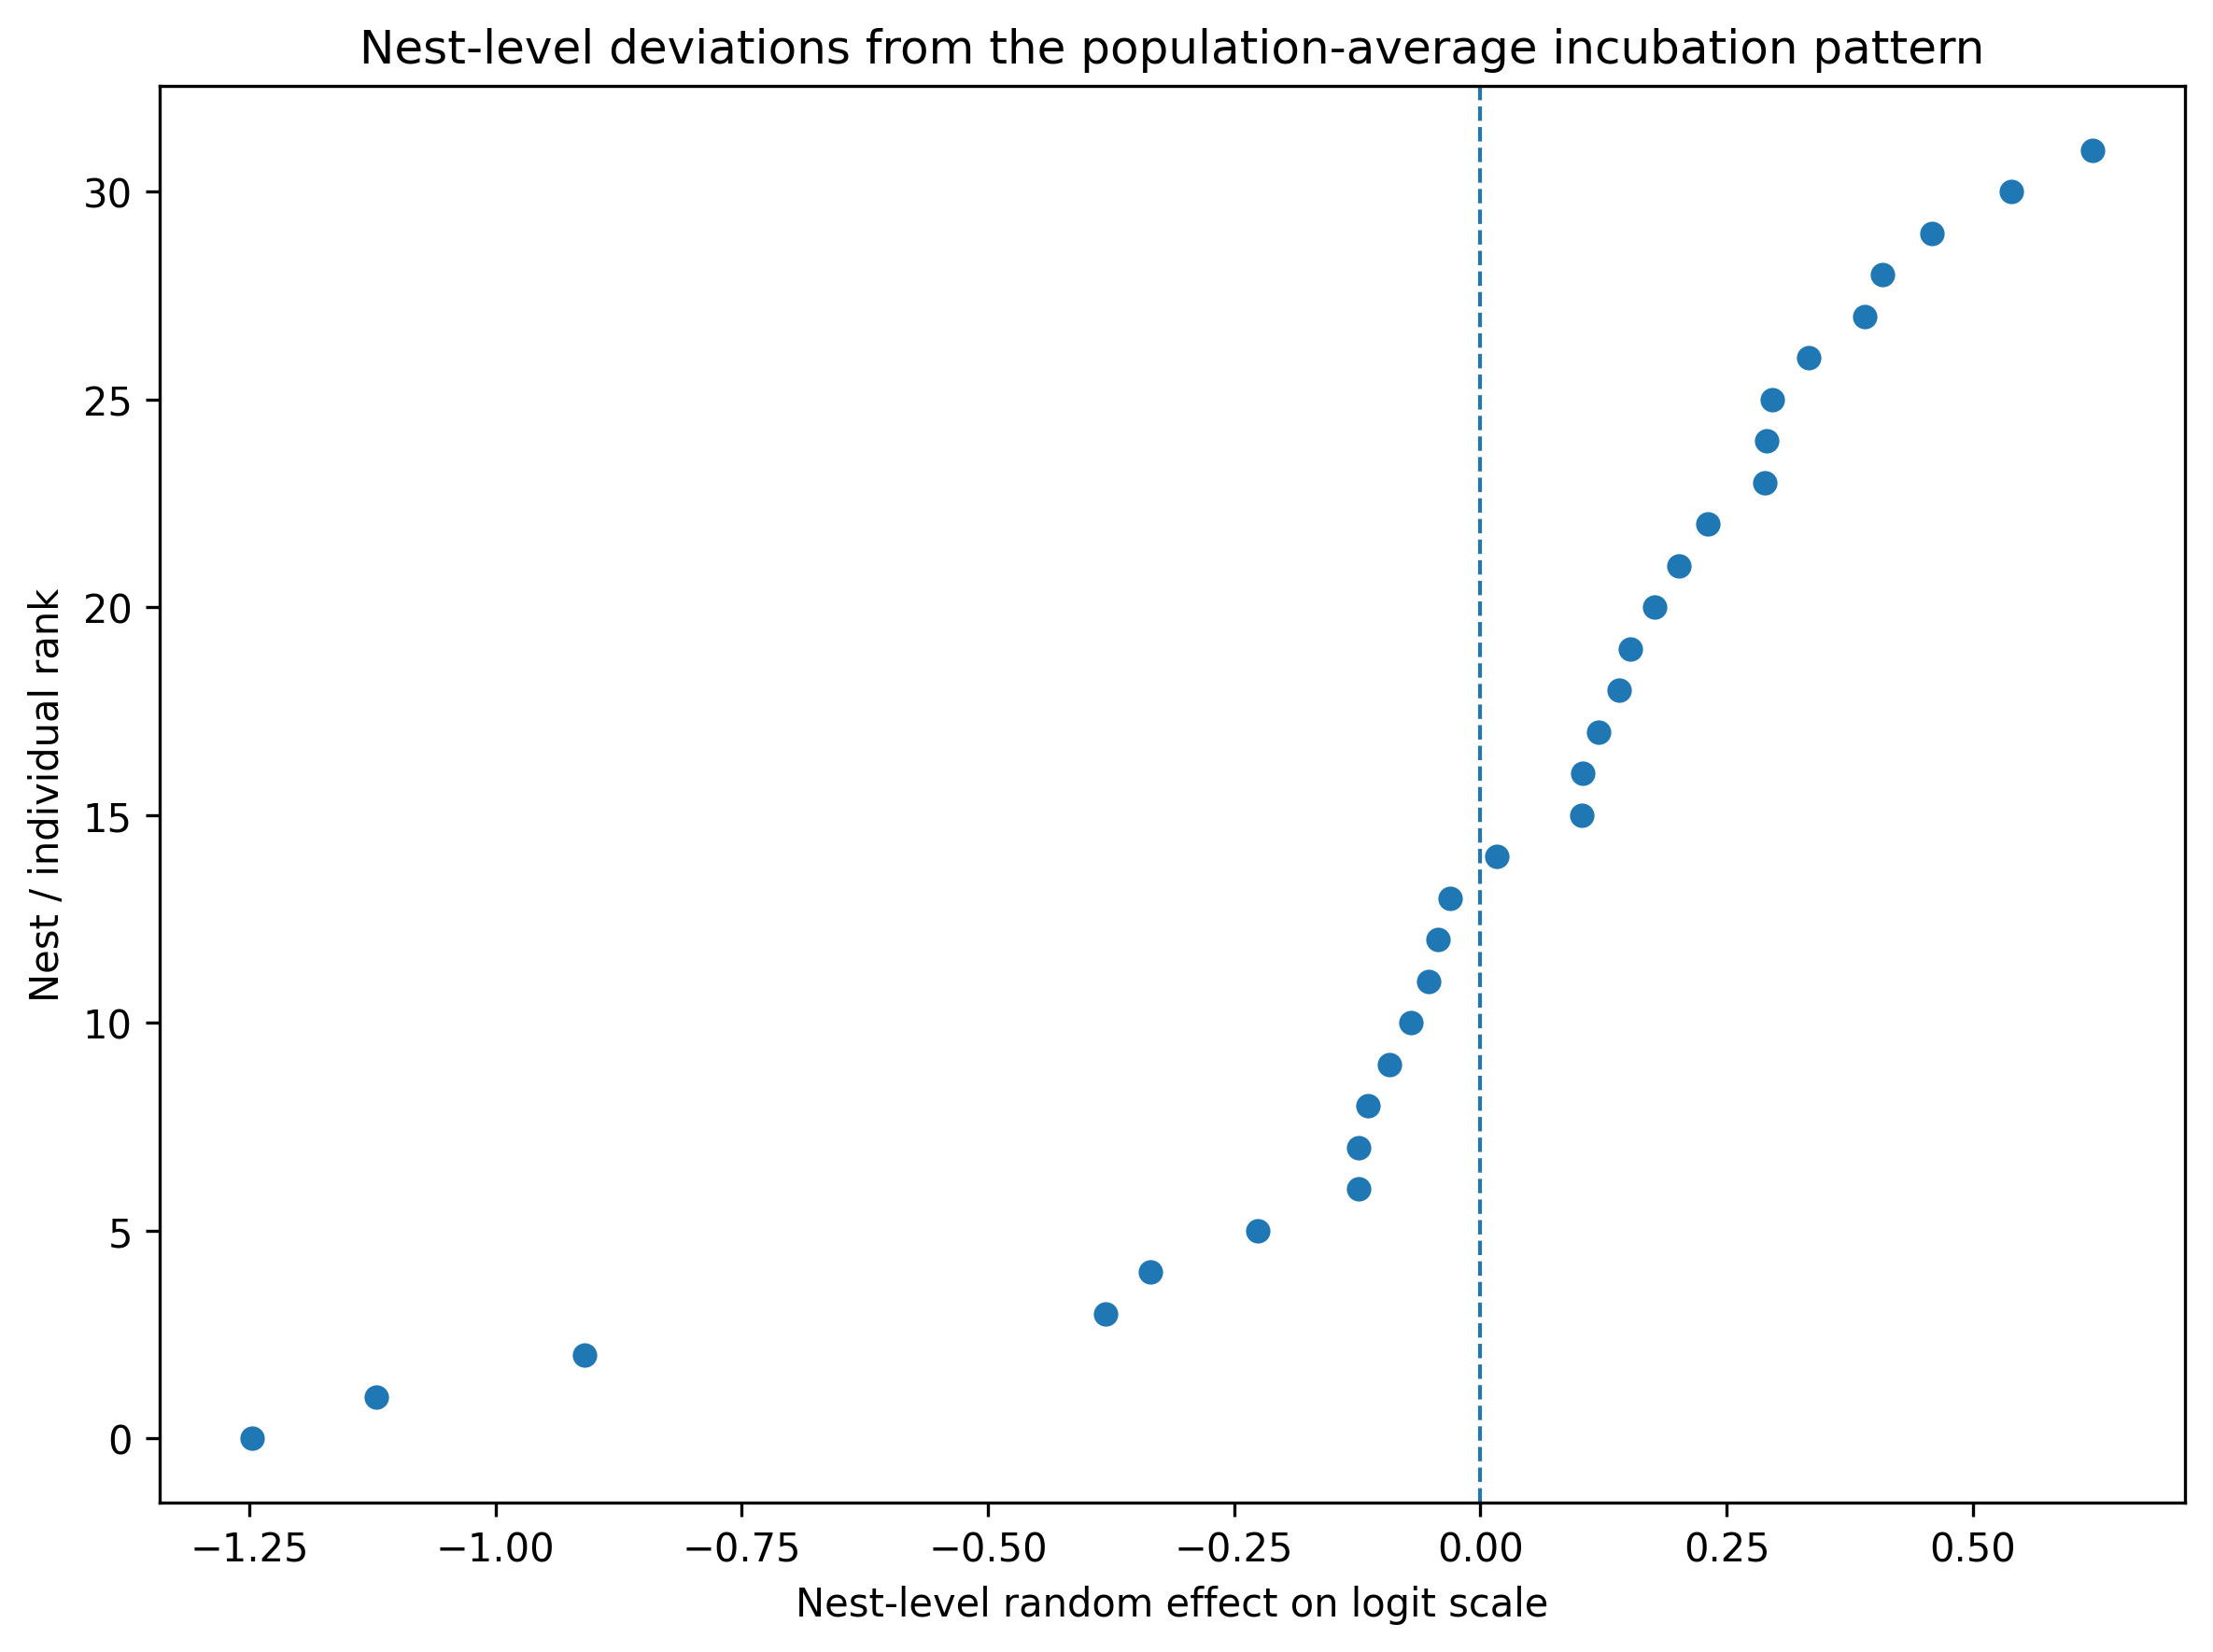

In [35]:
re_plot = re_df.sort_values("re_logit").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

ax.scatter(
    re_plot["re_logit"],
    np.arange(len(re_plot)),
    s=28
)

ax.axvline(0, linestyle="--", linewidth=1)

ax.set_xlabel("Nest-level random effect on logit scale")
ax.set_ylabel("Nest / individual rank")
ax.set_title("Nest-level deviations from the population-average incubation pattern")

plt.tight_layout()
plt.savefig("Figures/random_effects_Nest_ID_model_no_eggmass.png",
            dpi=300, transparent=True, bbox_inches="tight")
plt.show()

In [36]:
# Most negative deviations
re_df.sort_values("re_logit").head(10)

,term,re_logit,Nest_ID,odds_multiplier
24,s(Nest_ID).24,-1.247515,24,0.287218
20,s(Nest_ID).20,-1.121332,20,0.325845
16,s(Nest_ID).16,-0.909471,16,0.402737
11,s(Nest_ID).11,-0.380331,11,0.683635
10,s(Nest_ID).10,-0.335305,10,0.715120
6,s(Nest_ID).6,-0.225787,6,0.797888
3,s(Nest_ID).3,-0.123991,3,0.883387
1,s(Nest_ID).1,-0.123991,1,0.883387
31,s(Nest_ID).31,-0.113845,31,0.892396
2,s(Nest_ID).2,-0.092251,2,0.911876


In [37]:
# Most positive deviations
re_df.sort_values("re_logit").tail(10)

,term,re_logit,Nest_ID,odds_multiplier
22,s(Nest_ID).22,0.230473,22,1.259195
32,s(Nest_ID).32,0.288674,32,1.334657
17,s(Nest_ID).17,0.291051,17,1.337832
7,s(Nest_ID).7,0.296487,7,1.345125
26,s(Nest_ID).26,0.333408,26,1.395717
18,s(Nest_ID).18,0.390539,18,1.477777
19,s(Nest_ID).19,0.407968,19,1.503759
30,s(Nest_ID).30,0.458183,30,1.581199
27,s(Nest_ID).27,0.539403,27,1.714982
12,s(Nest_ID).12,0.621930,12,1.862519


In [38]:
top3_neg = re_df.sort_values("re_logit").head(3)
print(top3_neg[["Nest_ID", "re_logit", "odds_multiplier"]])

   Nest_ID  re_logit  odds_multiplier
24      24 -1.247515         0.287218
20      20 -1.121332         0.325845
16      16 -0.909471         0.402737


In [40]:
negativos = re_df[re_df["re_logit"] < 0].sort_values("re_logit")
print(negativos[["Nest_ID", "re_logit", "odds_multiplier"]])

   Nest_ID  re_logit  odds_multiplier
24      24 -1.247515         0.287218
20      20 -1.121332         0.325845
16      16 -0.909471         0.402737
11      11 -0.380331         0.683635
10      10 -0.335305         0.715120
6        6 -0.225787         0.797888
3        3 -0.123991         0.883387
1        1 -0.123991         0.883387
31      31 -0.113845         0.892396
2        2 -0.092251         0.911876
25      25 -0.070890         0.931564
29      29 -0.052806         0.948564
28      28 -0.042779         0.958123
5        5 -0.031084         0.969394


In [39]:
nest_info = (
    df_gamm[["Nest_ID", "Especie", "Estacion", "Elevacion"]]
    .drop_duplicates(subset="Nest_ID")
)

top3_neg_info = (
    re_df.sort_values("re_logit")
    .head(3)
    .merge(nest_info, on="Nest_ID", how="left")
)

print(top3_neg_info[["Nest_ID", "re_logit", "odds_multiplier", "Especie", "Estacion", "Elevacion"]])

  Nest_ID  re_logit  odds_multiplier Especie Estacion  Elevacion
0      24 -1.247515         0.287218     NaN      NaN        NaN
1      20 -1.121332         0.325845     NaN      NaN        NaN
2      16 -0.909471         0.402737     NaN      NaN        NaN


In [41]:
print("re_df Nest_ID examples:")
print(re_df["Nest_ID"].head(10).tolist())

print("\ndf_gamm Nest_ID examples:")
print(df_gamm["Nest_ID"].drop_duplicates().head(20).tolist())

re_df Nest_ID examples:
['24', '20', '16', '11', '10', '6', '3', '1', '31', '2']

df_gamm Nest_ID examples:
['Myioborus_melanocephalus_TU1a_DOR08_NEST_processed', 'Myioborus_melanocephalus_W1a_JAB08_EGG_processed_soloegg', 'Myioborus_melanocephalus_W1a_wjm08_processed_soloegg', 'Myioborus_melanocephalus_W1b_DOR11_EGG_processed_soloegg', 'Myioborus_melanocephalus_W1b_JAB08_processed_soloegg', 'Myioborus_melanocephalus_W1c_DOR11_EGG_processed_soloegg', 'Myioborus_melanocephalus_w1a_nap08_EGG_processed_soloegg', 'Myioborus_miniatus_SP12b_RVA10_EGG_processed_soloegg', 'Myioborus_miniatus_SP12c_RVA10_EGG_processed', 'Myioborus_miniatus_SP2a_DOR09_EGG_processed_soloegg', 'Myioborus_miniatus_SP2b_DOR09_EGG_processed_soloegg', 'Myioborus_miniatus_SPR01_JCB09_EGG_processed_soloegg', 'Myioborus_miniatus_TA02a_RA15_processed', 'Myioborus_miniatus_TA04B_MB15_processed', 'Myioborus_miniatus_TA04a_RVA14_processed', 'Myioborus_miniatus_TA04b_RVA14_processed', 'Myioborus_miniatus_TA07a_JH15_processed'

In [42]:
print((df_gamm["Nest_ID"].astype(str) == "24").sum())
print(df_gamm[df_gamm["Nest_ID"].astype(str).str.contains("24", na=False)]["Nest_ID"].unique())

0
['Myioborus_miniatus_TA24_EJ15_processed'
 'Myioborus_miniatus_TA24_JSZ14_processed']
